# SML Exp - 5

**K-NN CLASSIFICATION**

In [16]:
# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [17]:
# Loading the dataset
iris = sns.load_dataset('iris')
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [18]:
iris.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


In [19]:
iris.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


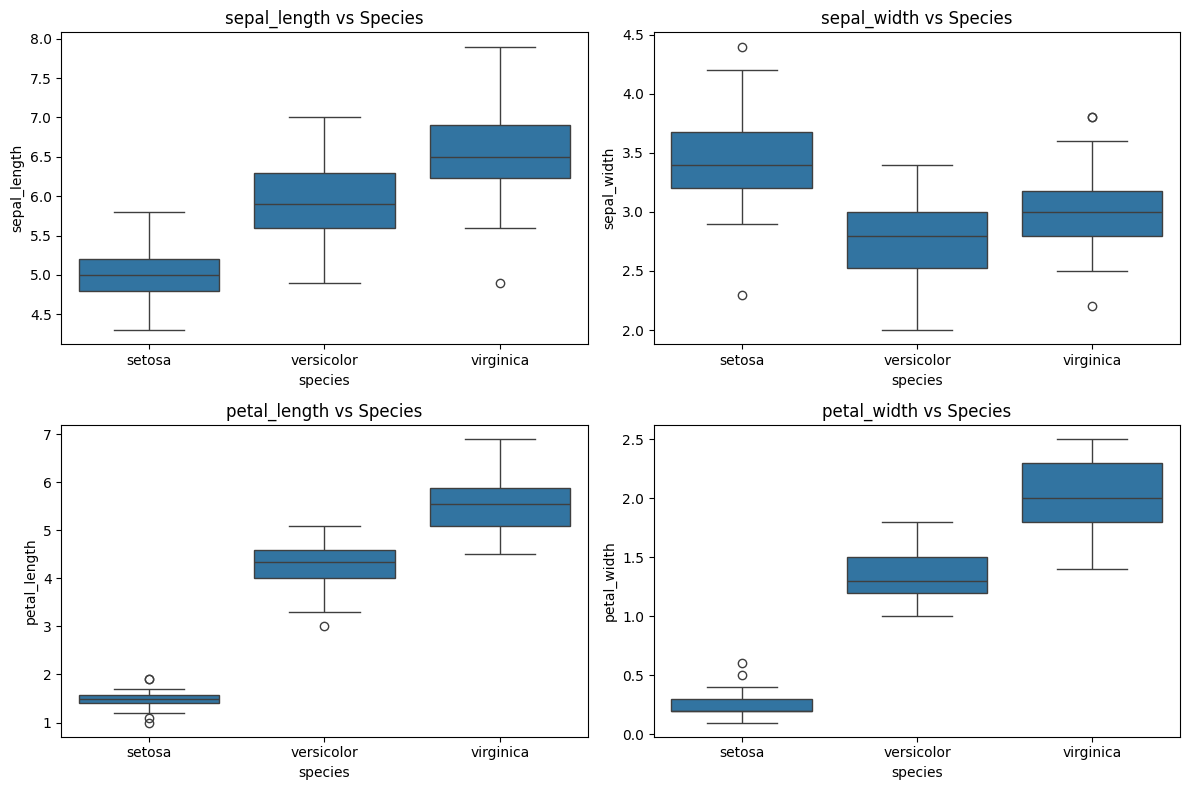

In [20]:
# Boxplots of features vs labels
features = iris.columns[:-1]
plt.figure(figsize=(12, 8))
for i, feature in enumerate(features):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(x='species', y=feature, data=iris)
    plt.title(f'{feature} vs Species')
plt.tight_layout()
plt.show()

In [21]:
# Separate X and y
X = iris.drop('species', axis=1)
y = iris['species']

In [22]:
# Train-Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1
)

In [23]:
# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [24]:
# Train KNN Classifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

In [25]:
# Model evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification report: \n", classification_report(y_test, y_pred))

Accuracy: 0.9666666666666667
Classification report: 
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        11
  versicolor       1.00      0.92      0.96        13
   virginica       0.86      1.00      0.92         6

    accuracy                           0.97        30
   macro avg       0.95      0.97      0.96        30
weighted avg       0.97      0.97      0.97        30



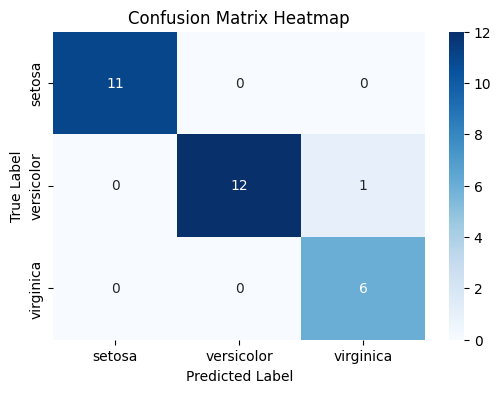

In [26]:
# Confusion matrix (visualisation)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=knn.classes_,
    yticklabels=knn.classes_
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Heatmap')
plt.show()

In [27]:
# IQR based outlier removal
iris_iqr = iris.copy()
for feature in iris.columns[:-1]:
    Q1 = iris_iqr[feature].quantile(0.25)
    Q3 = iris_iqr[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    iris_iqr = iris_iqr[
        (iris_iqr[feature] >= lower) &
        (iris_iqr[feature] <= upper)
    ]
iris_iqr.reset_index(drop=True, inplace=True)
print("Before IQR:", iris.shape)
print("After IQR:", iris_iqr.shape)


Before IQR: (150, 5)
After IQR: (146, 5)


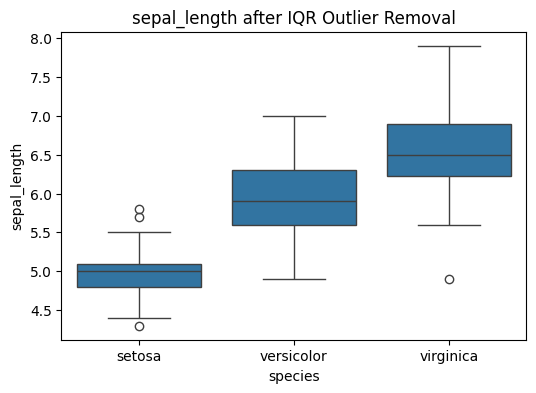

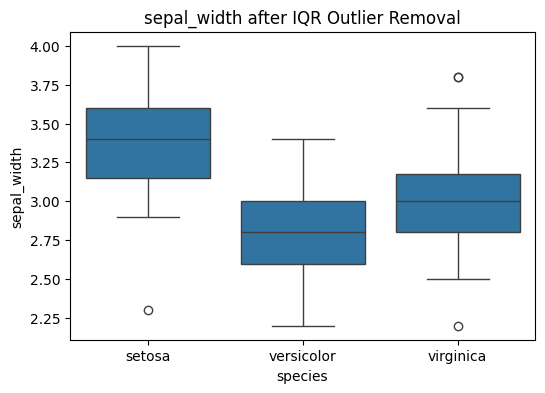

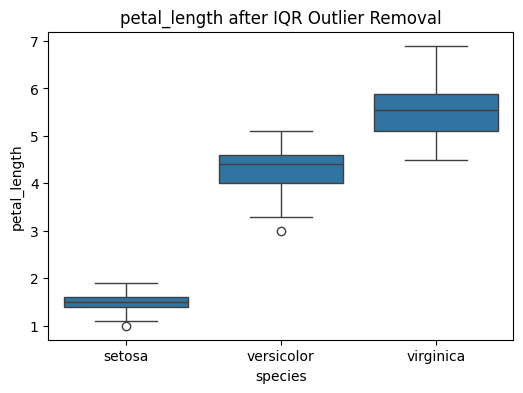

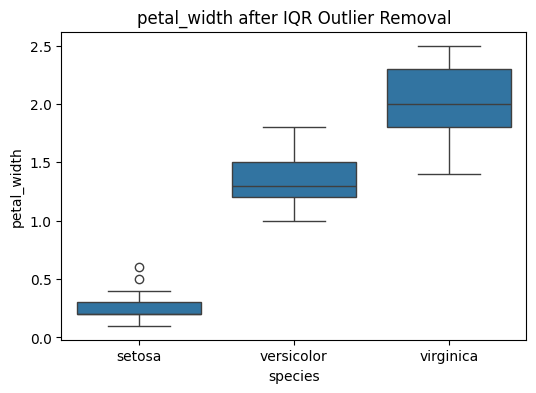

In [28]:
# Boxplot after outlier removal
for feature in iris.columns[:-1]:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x='species', y=feature, data=iris_iqr)
    plt.title(f'{feature} after IQR Outlier Removal')
    plt.show()

Model Accuracy after IQR Outlier Removal: 0.9333333333333333


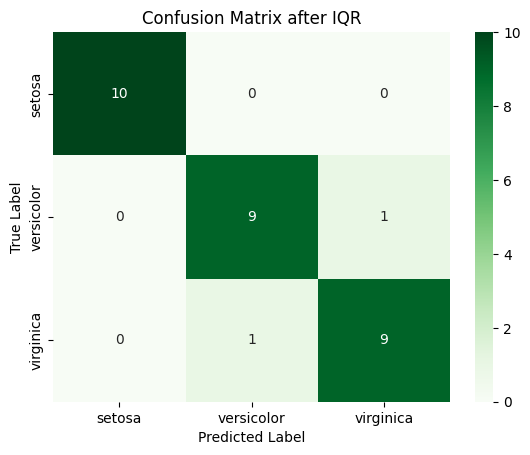

In [29]:
# KNN after IQR Outlier Removal

# Separate X and y after IQR
X_iqr = iris_iqr.drop('species', axis=1)
y_iqr = iris_iqr['species']

# Train-test split
X_train_iqr, X_test_iqr, y_train_iqr, y_test_iqr = train_test_split(
    X_iqr, y_iqr, test_size=0.2, random_state=1, stratify=y_iqr
)

# Feature scaling
scaler_iqr = StandardScaler()
X_train_iqr = scaler_iqr.fit_transform(X_train_iqr)
X_test_iqr = scaler_iqr.transform(X_test_iqr)

# Train KNN
knn_iqr = KNeighborsClassifier(n_neighbors=5)
knn_iqr.fit(X_train_iqr, y_train_iqr)

# Prediction
y_pred_iqr = knn_iqr.predict(X_test_iqr)

# Accuracy after IQR
print("Model Accuracy after IQR Outlier Removal:",
      accuracy_score(y_test_iqr, y_pred_iqr))

# Confusion matrix
cm_iqr = confusion_matrix(y_test_iqr, y_pred_iqr)
sns.heatmap(
    cm_iqr,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=knn_iqr.classes_,
    yticklabels=knn_iqr.classes_
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix after IQR")
plt.show()
